In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [11]:
# Import pustaka yang dibutuhkan
import pandas as pd

# Load dataset dari URL
url = 'https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/04.%20Week%204/Dataset/ReviewTokoBaju.csv'
df = pd.read_csv(url)
df


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [13]:

# Drop baris yang Review Text-nya kosong
df.dropna(subset=['Review Text'], inplace=True)

# Ambil fitur dan label
texts = df['Review Text'].astype(str).values
labels = df['Recommended IND'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Tokenisasi
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [14]:
# Konversi ke urutan token
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences
max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [27]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ambil kolom teks dan label
texts = df['Review Text'].astype(str).values
labels = df['Recommended IND'].values

# Tokenisasi teks
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Panjang maksimum sequence
maxlen = 150  # atau coba 100, 200 sesuai hasil evaluasi
X_pad = pad_sequences(sequences, maxlen=maxlen, padding='post')
vocab_size = len(tokenizer.word_index) + 1

# Split data
X_train_pad, X_temp_pad, y_train, y_temp = train_test_split(X_pad, labels, test_size=0.2, random_state=42)
X_val_pad, X_test_pad, y_val, y_test = train_test_split(X_temp_pad, y_temp, test_size=0.5, random_state=42)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0008)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    verbose=2
)

Epoch 1/15
283/283 - 5s - 17ms/step - accuracy: 0.8184 - loss: 0.4749 - val_accuracy: 0.8246 - val_loss: 0.4646
Epoch 2/15
283/283 - 5s - 18ms/step - accuracy: 0.8184 - loss: 0.4751 - val_accuracy: 0.8246 - val_loss: 0.4655
Epoch 3/15
283/283 - 5s - 16ms/step - accuracy: 0.8185 - loss: 0.4753 - val_accuracy: 0.8246 - val_loss: 0.4658
Epoch 4/15
283/283 - 5s - 16ms/step - accuracy: 0.8184 - loss: 0.4745 - val_accuracy: 0.8246 - val_loss: 0.4643
Epoch 5/15
283/283 - 5s - 17ms/step - accuracy: 0.8184 - loss: 0.4750 - val_accuracy: 0.8246 - val_loss: 0.4643
Epoch 6/15
283/283 - 4s - 16ms/step - accuracy: 0.8184 - loss: 0.4750 - val_accuracy: 0.8246 - val_loss: 0.4647
Epoch 7/15
283/283 - 6s - 20ms/step - accuracy: 0.8184 - loss: 0.4747 - val_accuracy: 0.8246 - val_loss: 0.4643
Epoch 8/15
283/283 - 4s - 16ms/step - accuracy: 0.8184 - loss: 0.4751 - val_accuracy: 0.8246 - val_loss: 0.4646
Epoch 9/15
283/283 - 5s - 18ms/step - accuracy: 0.8184 - loss: 0.4749 - val_accuracy: 0.8246 - val_loss:

In [42]:
# Ambil akurasi training dan validasi dari history
train_accuracy = history.history['accuracy'][-1] * 100
val_accuracy = history.history['val_accuracy'][-1] * 100

# Evaluasi testing
loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
test_accuracy *= 100

# --- Tampilkan akurasi ---
print("\n==========================")
print("🎯 Evaluation Results")
print("==========================")
print(f"📊 Training Accuracy   : {train_accuracy:.2f}%")
print(f"📈 Validation Accuracy : {val_accuracy:.2f}%")
print(f"✅ Testing Accuracy    : {test_accuracy:.2f}%")


# --- Prediksi dan laporan klasifikasi ---
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))




🎯 Evaluation Results
📊 Training Accuracy   : 81.84%
📈 Validation Accuracy : 82.46%
✅ Testing Accuracy    : 81.68%
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       415
           1       0.82      1.00      0.90      1850

    accuracy                           0.82      2265
   macro avg       0.41      0.50      0.45      2265
weighted avg       0.67      0.82      0.73      2265



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


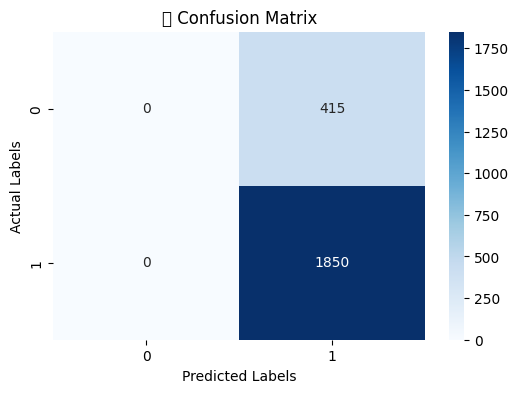

In [43]:
# --- Confusion Matrix ---
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Tampilkan matrix di plot terpisah
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('🧮 Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()


In [44]:
from tensorflow.keras.metrics import AUC

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy', AUC(name='auc')]
)


In [47]:
# Evaluasi testing
loss, test_accuracy, test_auc = model.evaluate(X_test_pad, y_test, verbose=0)

print(f"🔍 AUC Score (Testing) : {test_auc:.4f}")


🔍 AUC Score (Testing) : 0.5000


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


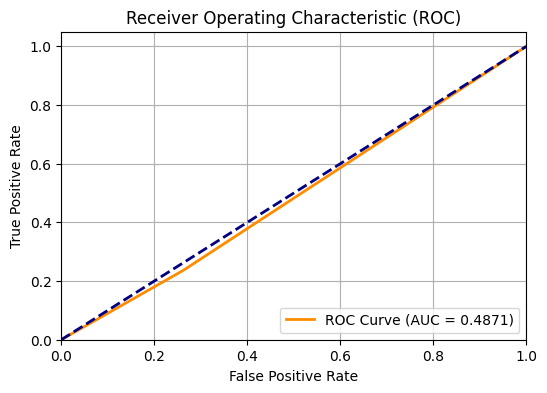

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Prediksi probabilitas
y_pred_prob = model.predict(X_test_pad).ravel()

# Hitung nilai FPR, TPR, dan threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Penjelasan Persamaan Matematika pada Model LSTM

Model **LSTM (Long Short-Term Memory)** merupakan jenis RNN (Recurrent Neural Network) yang dirancang untuk mengatasi masalah long-term dependencies dalam data deret waktu. LSTM menggunakan struktur "gates" (gerbang) untuk mengontrol aliran informasi.

Berikut adalah persamaan-persamaan utama dalam LSTM beserta penjelasannya:

### 1. Forget Gate

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

**Penjelasan:**

- Menentukan informasi mana dari cell state sebelumnya yang akan "dilupakan".
- \( \sigma \): Fungsi aktivasi sigmoid, menghasilkan nilai antara 0 dan 1.
- \( W_f \): Matriks bobot forget gate.
- \( h_{t-1} \): Hidden state dari waktu sebelumnya.
- \( x_t \): Input saat ini.
- \( b_f \): Bias forget gate.

### 2. Input Gate

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

**Penjelasan:**

- \( i_t \): Menentukan seberapa besar informasi baru akan ditambahkan ke cell state.
- \( \tilde{C}_t \): Kandidat nilai baru untuk sel memori, hasil dari fungsi aktivasi tanh.
- \( W_i, W_C \): Bobot untuk input dan kandidat memori.
- \( b_i, b_C \): Bias masing-masing.
- \( \tanh \): Fungsi aktivasi tanh, menghasilkan nilai antara -1 dan 1.

### 3. Cell State Update

$$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$$

**Penjelasan:**

- Cell state saat ini diperbarui dengan kombinasi dari:
  - Bagian dari cell state lama yang masih relevan (dengan \( f_t \)).
  - Informasi baru yang penting (dengan \( i_t \cdot \tilde{C}_t \)).
- \( * \): Perkalian elemen per elemen (Hadamard Product).


###  4. Output Gate dan Hidden State

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t * \tanh(C_t)
$$

**Penjelasan:**

- \( o_t \): Output gate, menentukan bagian mana dari cell state yang akan menjadi output.
- \( h_t \): Hidden state (output aktual) dari LSTM pada waktu t.
- Fungsi tanh digunakan untuk menskalakan cell state ke rentang -1 sampai 1.

## Kesimpulan

Setiap gate dalam LSTM memainkan peran penting untuk mempertahankan informasi yang relevan dan membuang informasi yang tidak diperlukan. Mekanisme ini membantu model LSTM untuk belajar dari urutan data yang panjang secara lebih stabil dibandingkan RNN standar.

---
